# Training

Linear Regression • Random Forest • ARIMA • Prophet

## 1. Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv('passenger_demand_final.csv')
df.head()

C:\Users\BUNNY\AppData\Local\Temp\ipykernel_21552\3666109386.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,year,month,day,hour,station,passenger_count
0,2026,1,19,6,Miyapur,70
1,2026,1,19,6,JNTU College,51
2,2026,1,19,6,KPHB Colony,51
3,2026,1,19,6,Kukatpally,68
4,2026,1,19,6,Ameerpet,46


## 2. Feature Engineering

In [61]:
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' +
    df['month'].astype(str) + '-' +
    df['day'].astype(str)
)
df['dayofweek'] = df['date'].dt.dayofweek
df.head()

,year,month,day,hour,station,passenger_count,ds,dayofweek,station_encoded,date
0,2026,1,19,6,Miyapur,70,2026-01-19 06:00:00,0,6,2026-01-19
1,2026,1,19,6,JNTU College,51,2026-01-19 06:00:00,0,2,2026-01-19
2,2026,1,19,6,KPHB Colony,51,2026-01-19 06:00:00,0,3,2026-01-19
3,2026,1,19,6,Kukatpally,68,2026-01-19 06:00:00,0,4,2026-01-19
4,2026,1,19,6,Ameerpet,46,2026-01-19 06:00:00,0,0,2026-01-19


In [62]:
from sklearn.preprocessing import LabelEncoder
import joblib

le = LabelEncoder()
df["station_encoded"] = le.fit_transform(df["station"])

df[["station", "station_encoded"]].head()


,station,station_encoded
0,Miyapur,6
1,JNTU College,2
2,KPHB Colony,3
3,Kukatpally,4
4,Ameerpet,0


## 3. Train-Test Split

In [66]:
from sklearn.model_selection import train_test_split
X = df[['station_encoded','year','month','day','hour','dayofweek']]
y = df['passenger_count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Linear Regression

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
(rmse_lr, mae_lr, r2_lr)

(32.96272765291155, 24.88653990472558, 0.00042908992279522273)

## 5. Decision trees


Decision Tree metrics:
RMSE: 16.164
MAE:  13.024
R²:   0.790


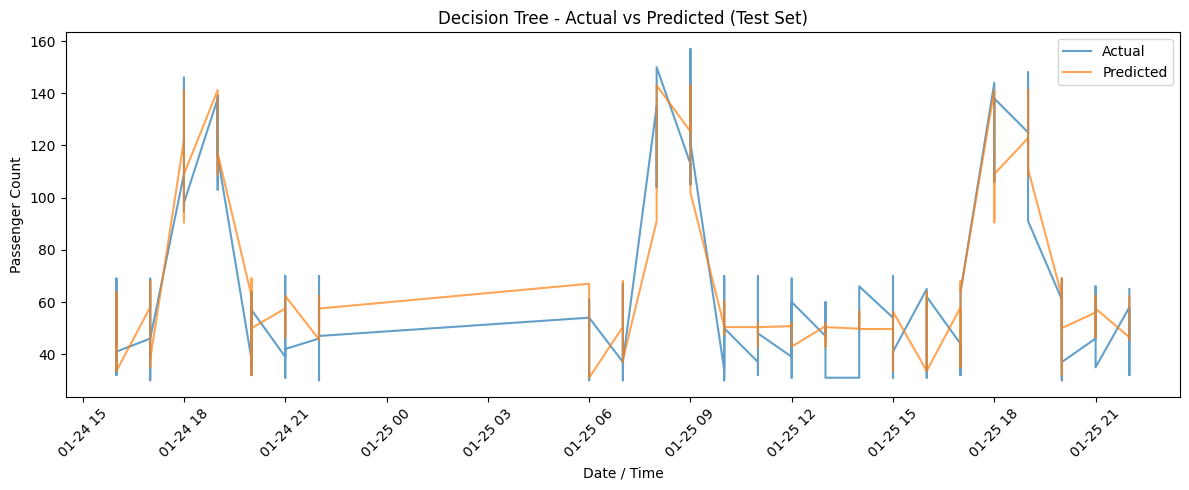

In [69]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("passenger_demand_final.csv")

# 2. Build datetime column and sort
df["ds"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values("ds")
df["dayofweek"] = df["ds"].dt.dayofweek


# 3. Encode station and create features
le = LabelEncoder()
df["station_encoded"] = le.fit_transform(df["station"])

X = df[["station_encoded", "year", "month", "day", "hour", "dayofweek"]]
y = df["passenger_count"]

# 4. Time-based split (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Corresponding dates for test set
test_dates = df["ds"].iloc[len(df) - len(y_test):]

# 5. Train Decision Tree
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# 6. Metrics
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree metrics:")
print(f"RMSE: {rmse_dt:.3f}")
print(f"MAE:  {mae_dt:.3f}")
print(f"R²:   {r2_dt:.3f}")

# 7. Plot Actual vs Predicted with dates on x-axis
plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test.values, label="Actual", alpha=0.7)
plt.plot(test_dates, y_pred_dt, label="Predicted", alpha=0.7)
plt.title("Decision Tree - Actual vs Predicted (Test Set)")
plt.xlabel("Date / Time")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Random Forest

Random Forest Metrics
RMSE: 16.043
MAE:  13.445
R²:   0.793


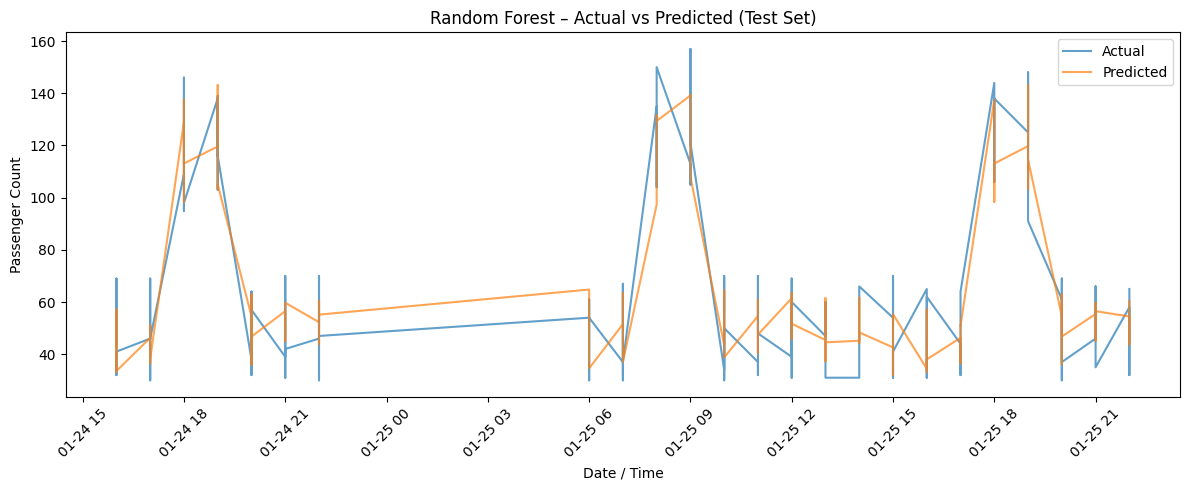

Random Forest model and encoder saved successfully


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. Load data
df = pd.read_csv("passenger_demand_final.csv")

# 2. Build datetime column and sort
df["ds"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values("ds")

# 3. Feature engineering
df["dayofweek"] = df["ds"].dt.dayofweek

le = LabelEncoder()
df["station_encoded"] = le.fit_transform(df["station"])

# 4. Prepare features & target (MUST MATCH DJANGO)
X = df[["station_encoded", "year", "month", "day", "hour", "dayofweek"]]
y = df["passenger_count"]

# 5. Time-based train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Test dates for plotting
test_dates = df["ds"].iloc[len(df) - len(y_test):]

# 6. Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 7. Predictions
y_pred_rf = rf.predict(X_test)

# 8. Evaluation metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Metrics")
print(f"RMSE: {rmse_rf:.3f}")
print(f"MAE:  {mae_rf:.3f}")
print(f"R²:   {r2_rf:.3f}")

# 9. Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test.values, label="Actual", alpha=0.7)
plt.plot(test_dates, y_pred_rf, label="Predicted", alpha=0.7)
plt.title("Random Forest – Actual vs Predicted (Test Set)")
plt.xlabel("Date / Time")
plt.ylabel("Passenger Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# # 10. Save model & encoder for Django
# joblib.dump(rf, "../models/rf_model.pkl")
# joblib.dump(le, "../models/station_encoder.pkl")

print("Random Forest model and encoder saved successfully")


## 7. Prophet

20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:45 - cmdstanpy - INFO - Chain [1] done processing
20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:45 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUNNY\Projects\transitml\venv\lib\site-packages\prophet\forecaster.py:1854: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



Prophet (Global) Metrics
RMSE: 253.356
MAE:  214.469
R²:   0.412


c:\Users\BUNNY\Projects\transitml\venv\lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\BUNNY\Projects\transitml\venv\lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



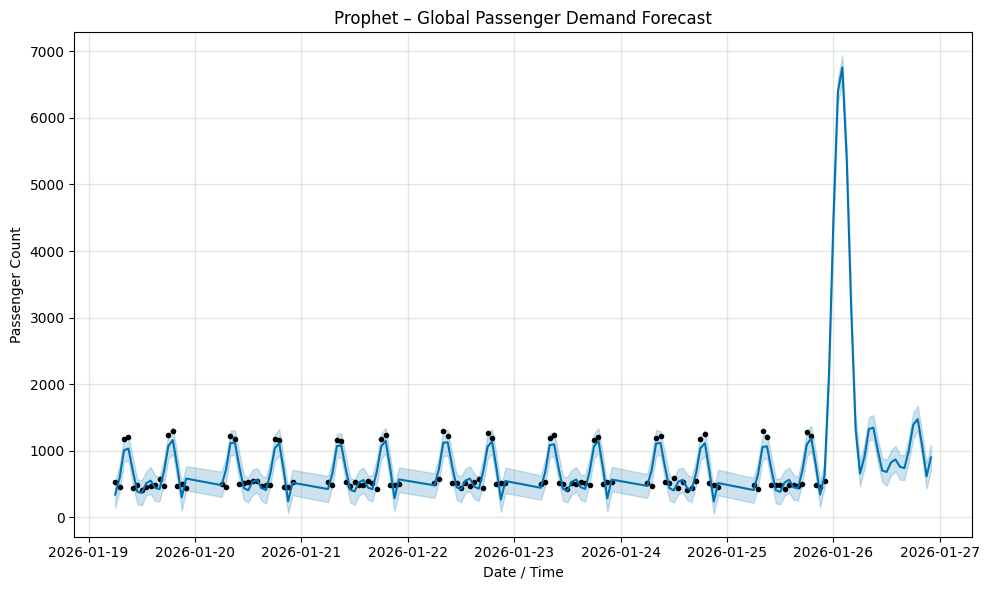

Prophet model saved successfully


In [73]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib
import pickle

# 1. Load data
df = pd.read_csv("passenger_demand_final.csv")

# 2. Build datetime column
df["ds"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# 3. Aggregate passenger count across all stations (GLOBAL DEMAND)
df_prophet = (
    df.groupby("ds")["passenger_count"]
    .sum()
    .reset_index()
    .rename(columns={"passenger_count": "y"})
)

# 4. Sort by time
df_prophet = df_prophet.sort_values("ds")

# 5. Time-based train–test split
test_size = 0.2
split_idx = int(len(df_prophet) * (1 - test_size))

train_df = df_prophet.iloc[:split_idx]
test_df = df_prophet.iloc[split_idx:]

# 6. Train Prophet model
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode="additive"
)

model.fit(train_df)

# 7. Predict on test data (for metrics)
forecast_test = model.predict(test_df[["ds"]])
y_true = test_df["y"].values
y_pred = forecast_test["yhat"].values

# 8. Evaluation metrics
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred))
mae_prophet = mean_absolute_error(y_true, y_pred)
r2_prophet = r2_score(y_true, y_pred)

print("Prophet (Global) Metrics")
print(f"RMSE: {rmse_prophet:.3f}")
print(f"MAE:  {mae_prophet:.3f}")
print(f"R²:   {r2_prophet:.3f}")

# 9. Train Prophet on FULL data (for future forecasting)
final_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode="additive"
)

final_model.fit(df_prophet)

# 10. Future prediction (next 24 hours)
future = final_model.make_future_dataframe(periods=24, freq="H")
forecast_full = final_model.predict(future)

# 11. Plot forecast
fig = final_model.plot(forecast_full)
plt.title("Prophet – Global Passenger Demand Forecast")
plt.xlabel("Date / Time")
plt.ylabel("Passenger Count")
plt.tight_layout()
plt.show()

# # 12. Save Prophet model for Django
# with open("../models/prophet_model.pkl", "wb") as f:
#     pickle.dump(final_model, f)

print("Prophet model saved successfully")


## 8. Model Comparison Summary

In [42]:
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Prophet", "Decision Tree"],
    "RMSE":  [rmse_lr, rmse_rf, rmse_prophet, rmse_dt],
    "MAE":   [mae_lr, mae_rf, mae_prophet, mae_dt],
    "R2":    [r2_lr, r2_rf, r2_prophet, r2_dt],
})

metrics_df = metrics_df.sort_values("RMSE").reset_index(drop=True)
metrics_df



,Model,RMSE,MAE,R2
0,Random Forest,14.168548,11.752645,0.838321
1,Decision Tree,16.163931,13.023624,0.789575
2,Prophet,21.562580,18.644463,0.652457
3,Linear Regression,33.928682,26.626050,-0.005636


In [80]:
import os
import joblib
import pickle
from sklearn.preprocessing import LabelEncoder

def get_project_root():
    current = os.getcwd()
    while current != os.path.dirname(current):
        if "manage.py" in os.listdir(current):
            return current
        current = os.path.dirname(current)
    raise RuntimeError("Project root not found")

PROJECT_ROOT = get_project_root()

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODEL_DIR, exist_ok=True)


joblib.dump(rf, os.path.join(MODEL_DIR, "rf_model.pkl"))
joblib.dump(dt, os.path.join(MODEL_DIR, "dt_model.pkl"))

le = LabelEncoder()
df["station_encoded"] = le.fit_transform(df["station"])
joblib.dump(le, os.path.join(MODEL_DIR, "station_encoder.pkl"))

with open(os.path.join(MODEL_DIR, "prophet_model.pkl"), "wb") as f:
    pickle.dump(model, f)
